# DOAC Case Study: Do Manufacturer Payments Predict Prescribing?
## CMS Open Payments (Program Year 2023) × Medicare Part D Prescribers (Calendar Year 2024)
**Author:** Kieran Lucus | **Date:** July 2026

---

### Study Design
This notebook examines whether pharmaceutical manufacturer payments to physicians — disclosed under the Physician Payments Sunshine Act — are associated with higher Medicare prescribing volume for two direct oral anticoagulants: **Eliquis (apixaban)** and **Xarelto (rivaroxaban)**.

A **lagged design** is used: Open Payments data from **Program Year 2023** is paired against Part D prescribing data from **Calendar Year 2024**, establishing temporal ordering consistent with a payment-precedes-prescribing hypothesis.

### Notebook Structure
1. Setup & Data Loading
2. Data Exploration & Quality Checks
3. Open Payments Cleaning
4. Part D Cleaning & Specialty Bucketing
5. Master Analysis Table Construction
6. Core Findings: Paid vs. Unpaid Prescribing
7. Dose-Response: Payment Tier Analysis
8. Payment Nature & Engagement Type Analysis
9. Beneficiary-Level Analysis (Volume vs. Intensity)
10. Geographic Analysis
11. Brand Comparison: Eliquis vs. Xarelto
12. Visualizations

## 1. Setup & Data Loading

In [1]:
# Cell 1: Import libraries and connect to DuckDB
# DuckDB allows querying large CSV files directly without loading them into memory.
# The .duckdb file persists all tables between sessions — re-running this cell
# reconnects to the existing database without losing any previously created tables.

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

con = duckdb.connect('doac_analysis.duckdb')
print('Connected to doac_analysis.duckdb')

Connected to doac_analysis.duckdb


In [2]:
# Cell 2: Load raw source files into DuckDB tables
# UPDATE THE FILE PATHS BELOW to match your local directory.
# read_csv_auto() infers column types, delimiters, and quoting automatically.
# CREATE OR REPLACE means re-running this cell safely overwrites existing tables.
# Forward slashes are used instead of backslashes to avoid Python Unicode escape errors.

OPEN_PAYMENTS_PATH = r'C:/Users/19735/Desktop/doac-case-study/OP_DTL_GNRL_PGYR2023_P06302026_06032026.csv'
PARTD_PATH         = r'C:/Users/19735/Desktop/doac-case-study/Medicare_Part_D_Prescribers_by_Provider_and_Drug_2024.csv'

con.sql(f"""
    CREATE OR REPLACE TABLE open_payments_raw AS
    SELECT * FROM read_csv_auto('{OPEN_PAYMENTS_PATH}')
""")

con.sql(f"""
    CREATE OR REPLACE TABLE partd_prescriber_raw AS
    SELECT * FROM read_csv_auto('{PARTD_PATH}')
""")

print('Tables loaded successfully.')
con.sql('SHOW TABLES').show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Tables loaded successfully.
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ open_payments_raw    │
│ partd_prescriber_raw │
└──────────────────────┘



## 2. Data Exploration & Quality Checks

In [3]:
# Cell 3: Inspect column names in both raw tables
# This is essential before writing any filter or join queries —
# CMS uses long, non-intuitive column names that must be referenced exactly.

print('=== Open Payments columns ===')
print(con.sql('DESCRIBE open_payments_raw').df()['column_name'].tolist())

print('\n=== Part D Prescriber columns ===')
print(con.sql('DESCRIBE partd_prescriber_raw').df()['column_name'].tolist())

=== Open Payments columns ===
['Change_Type', 'Covered_Recipient_Type', 'Teaching_Hospital_CCN', 'Teaching_Hospital_ID', 'Teaching_Hospital_Name', 'Covered_Recipient_Profile_ID', 'Covered_Recipient_NPI', 'Covered_Recipient_First_Name', 'Covered_Recipient_Middle_Name', 'Covered_Recipient_Last_Name', 'Covered_Recipient_Name_Suffix', 'Recipient_Primary_Business_Street_Address_Line1', 'Recipient_Primary_Business_Street_Address_Line2', 'Recipient_City', 'Recipient_State', 'Recipient_Zip_Code', 'Recipient_Country', 'Recipient_Province', 'Recipient_Postal_Code', 'Covered_Recipient_Primary_Type_1', 'Covered_Recipient_Primary_Type_2', 'Covered_Recipient_Primary_Type_3', 'Covered_Recipient_Primary_Type_4', 'Covered_Recipient_Primary_Type_5', 'Covered_Recipient_Primary_Type_6', 'Covered_Recipient_Specialty_1', 'Covered_Recipient_Specialty_2', 'Covered_Recipient_Specialty_3', 'Covered_Recipient_Specialty_4', 'Covered_Recipient_Specialty_5', 'Covered_Recipient_Specialty_6', 'Covered_Recipient_Licen

In [5]:
# Cell 4: Check row counts for both raw files
# Open Payments 2023 General Payments file should contain ~14.7 million rows.
# Part D 2024 file contains one row per prescriber-drug pair (NPI × brand name).

op_count = con.sql('SELECT COUNT(*) AS total_rows FROM open_payments_raw').df()
partd_count = con.sql('SELECT COUNT(*) AS total_rows FROM partd_prescriber_raw').df()

print('Open Payments raw rows:', f"{op_count['total_rows'][0]:,}")
print('Part D raw rows:       ', f"{partd_count['total_rows'][0]:,}")

Open Payments raw rows: 14,734,121
Part D raw rows:        28,023,892


In [6]:
# Cell 5: Check recipient types in Open Payments
# We will later filter to 'Covered Recipient Physician' only,
# excluding teaching hospitals and non-physician practitioners.

con.sql('SELECT DISTINCT Covered_Recipient_Type FROM open_payments_raw').show()

┌──────────────────────────────────────────────┐
│            Covered_Recipient_Type            │
│                   varchar                    │
├──────────────────────────────────────────────┤
│ Covered Recipient Non-Physician Practitioner │
│ Covered Recipient Physician                  │
│ Covered Recipient Teaching Hospital          │
└──────────────────────────────────────────────┘



In [7]:
# Cell 6: Check all payment nature types in Open Payments
# These 16 categories define the type of transfer: meals, speaker fees,
# consulting agreements, travel, grants, royalties, etc.
# Used later to classify physician engagement types.

con.sql("""
    SELECT DISTINCT Nature_of_Payment_or_Transfer_of_Value
    FROM open_payments_raw
    ORDER BY 1
""").show(max_rows=20)

┌────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│                                                       Nature_of_Payment_or_Transfer_of_Value                                                       │
│                                                                      varchar                                                                       │
├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ Acquisitions                                                                                                                                       │
│ Charitable Contribution                                                                                                                            │
│ Compensation for services other than consulting, including serving as faculty or as a speake

In [8]:
# Cell 7: CRITICAL — Case sensitivity check for drug name matching
# LIKE (case-sensitive) returns 0 rows; ILIKE (case-insensitive) returns 266,120.
# This confirms drug names are stored in UPPERCASE in the 2023 file (e.g., 'ELIQUIS').
# All subsequent drug name filters use ILIKE to avoid missing records.

case_sensitive = con.sql("""
    SELECT COUNT(*) AS like_matches FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 LIKE '%Eliquis%'
""").df()['like_matches'][0]

case_insensitive = con.sql("""
    SELECT COUNT(*) AS ilike_matches FROM open_payments_raw
    WHERE Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
""").df()['ilike_matches'][0]

print(f'LIKE (case-sensitive):    {case_sensitive:,} matches')
print(f'ILIKE (case-insensitive): {case_insensitive:,} matches')
print('Conclusion: drug names are stored in UPPERCASE — always use ILIKE.')

LIKE (case-sensitive):    0 matches
ILIKE (case-insensitive): 147,479 matches
Conclusion: drug names are stored in UPPERCASE — always use ILIKE.


In [9]:
# Cell 8: Check for generic name usage in Part D
# Verifies that Eliquis and Xarelto are filed under brand names (not apixaban/rivaroxaban)
# in the Brnd_Name column. If generics appear under Brnd_Name, we would need to adjust
# the filter. Post-patent-expiration (Xarelto, 2023), this is worth confirming.

con.sql("""
    SELECT DISTINCT Brnd_Name, Gnrc_Name, COUNT(*) as cnt
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%apixaban%'
        OR Brnd_Name ILIKE '%rivaroxaban%'
        OR Gnrc_Name ILIKE '%apixaban%'
        OR Gnrc_Name ILIKE '%rivaroxaban%'
    GROUP BY Brnd_Name, Gnrc_Name
    ORDER BY cnt DESC
""").show()
# Expected: only Eliquis/Xarelto appear as Brnd_Name — no generic brand names.

┌───────────┬─────────────┬────────┐
│ Brnd_Name │  Gnrc_Name  │  cnt   │
│  varchar  │   varchar   │ int64  │
├───────────┼─────────────┼────────┤
│ Eliquis   │ Apixaban    │ 264286 │
│ Xarelto   │ Rivaroxaban │ 134291 │
└───────────┴─────────────┴────────┘



In [10]:
# Cell 9: Verify manufacturer name fragmentation in Open Payments
# CMS requires manufacturers to file under their legal entity name,
# resulting in many subsidiary variants per parent company.
# This confirms we need to normalize manufacturer names in cleaning.

con.sql("""
    SELECT Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name,
           COUNT(*) AS row_count
    FROM open_payments_raw
    WHERE Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bristol%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Pfizer%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Squibb%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Celgene%'
        OR Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Johnson%'
    GROUP BY 1
    ORDER BY 2 DESC
""").show(max_rows=30)

┌───────────────────────────────────────────────────────────────┬───────────┐
│ Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name │ row_count │
│                            varchar                            │   int64   │
├───────────────────────────────────────────────────────────────┼───────────┤
│ PFIZER INC.                                                   │    515135 │
│ Janssen Biotech, Inc.                                         │    257833 │
│ Janssen Pharmaceuticals, Inc                                  │    209118 │
│ E.R. Squibb & Sons, L.L.C.                                    │    207201 │
│ Bayer Healthcare Pharmaceuticals Inc.                         │    186426 │
│ Celgene Corporation                                           │    103452 │
│ Johnson & Johnson Vision Care, Inc.                           │     36577 │
│ Janssen Scientific Affairs, LLC                               │      7880 │
│ Johnson & Johnson Surgical Vision, Inc.                       

## 3. Open Payments Cleaning

In [15]:
# Cell 10: Create cleaned Open Payments DOAC table
# Filters to physician recipients with at least one Eliquis or Xarelto drug name field.
# Key decisions:
#   - ILIKE used throughout (drug names stored in uppercase)
#   - NPI cast to VARCHAR to match Part D NPI type for joining
#   - Manufacturer normalized from ~15 subsidiary filing names to 4 parent companies:
#       Pfizer, Janssen (J&J), Bayer, Bristol Myers Squibb
#     NOTE: %Squibb% catches 'E.R. Squibb & Sons' (28,717 records that would otherwise
#     be NULL), %Celgene% catches BMS subsidiary Celgene Corp (28 records),
#     %Johnson% catches J&J parent-company filings (15 records)
#   - Brand column tags each record as Eliquis or Xarelto based on drug name fields
#   - Checks all 5 drug name fields (a single payment can list up to 5 products)

con.sql("""
    CREATE OR REPLACE TABLE open_payments_doac_clean AS
    SELECT
        CAST(Covered_Recipient_NPI AS VARCHAR) AS npi,
        Covered_Recipient_Specialty_1 AS raw_specialty,
        Recipient_State AS state,
        Nature_of_Payment_or_Transfer_of_Value AS payment_nature,
        Total_Amount_of_Payment_USDollars AS payment_amount,
        Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name AS manufacturer_raw,
        CASE
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Pfizer%'     THEN 'Pfizer'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%PBG Puerto%' THEN 'Pfizer'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Janssen%'    THEN 'Janssen (J&J)'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Johnson%'    THEN 'Janssen (J&J)'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bayer%'      THEN 'Bayer'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Bristol%'    THEN 'Bristol Myers Squibb'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Squibb%'     THEN 'Bristol Myers Squibb'
            WHEN Applicable_Manufacturer_or_Applicable_GPO_Making_Payment_Name ILIKE '%Celgene%'    THEN 'Bristol Myers Squibb'
        END AS manufacturer,
        CASE
            WHEN Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Eliquis%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Eliquis%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Eliquis%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Eliquis%'
                THEN 'Eliquis'
            WHEN Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Xarelto%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Xarelto%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Xarelto%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Xarelto%'
              OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Xarelto%'
                THEN 'Xarelto'
        END AS brand
    FROM open_payments_raw
    WHERE Covered_Recipient_Type = 'Covered Recipient Physician'
        AND Covered_Recipient_NPI IS NOT NULL
        AND (
            Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Eliquis%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_1 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_2 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_3 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_4 ILIKE '%Xarelto%'
            OR Name_of_Drug_or_Biological_or_Device_or_Medical_Supply_5 ILIKE '%Xarelto%'
        )
""")

print(con.sql('SELECT COUNT(*) FROM open_payments_doac_clean').df())
# Expected: ~181,452 rows

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   count_star()
0        181452


In [16]:
# Cell 11: Verify no NULL manufacturers remain after normalization
# If this returns rows, those manufacturer names need to be added
# to the CASE statement in Cell 10 above.

nulls = con.sql("""
    SELECT manufacturer_raw, COUNT(*) as cnt
    FROM open_payments_doac_clean
    WHERE manufacturer IS NULL
    GROUP BY manufacturer_raw
    ORDER BY cnt DESC
""").df()

if len(nulls) == 0:
    print('✓ All manufacturer names successfully normalized — no NULLs.')
else:
    print(f'WARNING: {nulls["cnt"].sum()} records have NULL manufacturer. Review below:')
    print(nulls)

✓ All manufacturer names successfully normalized — no NULLs.


In [17]:
# Cell 12: Verify brand split and check for generic name records
# Confirms that 0 records appear with generic names (apixaban/rivaroxaban)
# as the brand identifier — all records correctly tagged as Eliquis or Xarelto.

con.sql("""
    SELECT brand, COUNT(*) AS record_count
    FROM open_payments_doac_clean
    GROUP BY brand
""").show()
# Expected: Eliquis ~103,153 | Xarelto ~78,299

┌─────────┬──────────────┐
│  brand  │ record_count │
│ varchar │    int64     │
├─────────┼──────────────┤
│ Eliquis │       103153 │
│ Xarelto │        78299 │
└─────────┴──────────────┘



In [18]:
# Cell 13: Aggregate Open Payments to one row per physician-brand pair
# Each physician may have multiple payment records across the year.
# This collapses them into a single summary row per NPI × brand combination.
#
# Key aggregations:
#   - num_payments: total number of payment transactions
#   - total_payment_amount: sum of all payment amounts (USD)
#   - top_payment_nature: modal (most frequent) payment type
#
# New engagement flag columns (added to address limitation of modal-only approach):
#   - received_X_payment: binary flag (1/0) for whether the physician received
#     ANY payment of that type, regardless of frequency
#   - highest_engagement_tier: the highest-value payment type received
#     (4=Speaker, 3=Consulting, 2=Travel, 1=Education, 0=Food only)
#     This classifies physicians by their peak engagement level rather than
#     their most frequent one — more analytically meaningful.

con.sql("""
    CREATE OR REPLACE TABLE open_payments_doac_agg AS
    SELECT
        npi,
        brand,
        ANY_VALUE(raw_specialty)    AS raw_specialty,
        ANY_VALUE(state)            AS state,
        COUNT(*)                    AS num_payments,
        SUM(payment_amount)         AS total_payment_amount,
        MODE(payment_nature)        AS top_payment_nature,

        -- Any-payment flags
        MAX(CASE WHEN payment_nature ILIKE '%speaker%'
                  OR payment_nature ILIKE '%faculty%'  THEN 1 ELSE 0 END) AS received_speaker_payment,
        MAX(CASE WHEN payment_nature ILIKE '%consulting%'               THEN 1 ELSE 0 END) AS received_consulting_payment,
        MAX(CASE WHEN payment_nature ILIKE '%food%'
                  OR payment_nature ILIKE '%beverage%' THEN 1 ELSE 0 END) AS received_food_payment,
        MAX(CASE WHEN payment_nature ILIKE '%travel%'
                  OR payment_nature ILIKE '%lodging%'  THEN 1 ELSE 0 END) AS received_travel_payment,
        MAX(CASE WHEN payment_nature ILIKE '%education%'               THEN 1 ELSE 0 END) AS received_education_payment,

        -- Highest engagement tier received
        MAX(CASE
            WHEN payment_nature ILIKE '%speaker%'
              OR payment_nature ILIKE '%faculty%'  THEN 4
            WHEN payment_nature ILIKE '%consulting%'               THEN 3
            WHEN payment_nature ILIKE '%travel%'
              OR payment_nature ILIKE '%lodging%'  THEN 2
            WHEN payment_nature ILIKE '%education%'               THEN 1
            ELSE 0
        END) AS highest_engagement_tier

    FROM open_payments_doac_clean
    GROUP BY npi, brand
""")

# Sanity check: compare any-payment vs modal counts
con.sql("""
    SELECT brand,
        COUNT(*)                        AS total_paid_physicians,
        SUM(received_speaker_payment)   AS any_speaker_payment,
        SUM(CASE WHEN top_payment_nature ILIKE '%speaker%'
                  OR top_payment_nature ILIKE '%faculty%'
            THEN 1 ELSE 0 END)          AS modal_speaker_payment,
        SUM(received_consulting_payment) AS any_consulting_payment,
        SUM(received_food_payment)      AS any_food_payment,
        SUM(received_travel_payment)    AS any_travel_payment,
        SUM(received_education_payment) AS any_education_payment
    FROM open_payments_doac_agg
    GROUP BY brand
""").show()

┌─────────┬───────────────────────┬─────────────────────┬───────────────────────┬────────────────────────┬──────────────────┬────────────────────┬───────────────────────┐
│  brand  │ total_paid_physicians │ any_speaker_payment │ modal_speaker_payment │ any_consulting_payment │ any_food_payment │ any_travel_payment │ any_education_payment │
│ varchar │         int64         │       int128        │        int128         │         int128         │      int128      │       int128       │        int128         │
├─────────┼───────────────────────┼─────────────────────┼───────────────────────┼────────────────────────┼──────────────────┼────────────────────┼───────────────────────┤
│ Xarelto │                 28479 │                 333 │                   116 │                    358 │            28363 │                155 │                   527 │
│ Eliquis │                 34473 │                  62 │                    21 │                     75 │            34442 │                 20 

## 4. Part D Cleaning & Specialty Bucketing

In [19]:
# Cell 14: Create cleaned Part D DOAC table
# Filters to Eliquis and Xarelto records only.
# NPI cast to VARCHAR to match Open Payments NPI type for downstream joining.
# Selects only the fields needed for analysis.

con.sql("""
    CREATE OR REPLACE TABLE partd_doac_clean AS
    SELECT
        CAST(Prscrbr_NPI AS VARCHAR) AS npi,
        Prscrbr_Type                 AS raw_specialty,
        Prscrbr_State_Abrvtn         AS state,
        Brnd_Name                    AS brand,
        Tot_Clms                     AS total_claims,
        Tot_Day_Suply                AS total_day_supply,
        Tot_Drug_Cst                 AS total_drug_cost
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%'
       OR Brnd_Name ILIKE '%xarelto%'
""")

con.sql('SELECT brand, COUNT(*) FROM partd_doac_clean GROUP BY brand').show()
# Expected: Eliquis 264,286 | Xarelto 134,291

┌─────────┬──────────────┐
│  brand  │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ Xarelto │       134291 │
│ Eliquis │       264286 │
└─────────┴──────────────┘



In [20]:
# Cell 15: Create specialty buckets
# Raw specialty strings in Part D use a pipe-delimited hierarchical format
# (e.g., 'Allopathic & Osteopathic Physicians|Internal Medicine|Cardiology')
# that cannot be used for grouping directly. These are bucketed into 6 categories.
#
# Key fix: '%cardiac%' was added alongside '%cardio%' after discovering that
# 'Clinical Cardiac Electrophysiology' was being misclassified as 'Other'
# because 'cardiac' does not contain the substring 'cardio'.
# '%general practice%' added to capture GPs alongside Family Medicine.
# '%hospitalist%' given its own bucket since formulary constraints
# produce a structurally different payment-prescribing pattern.

con.sql("""
    CREATE OR REPLACE TABLE partd_doac_bucketed AS
    SELECT *,
        CASE
            WHEN raw_specialty ILIKE '%cardio%'
              OR raw_specialty ILIKE '%cardiac%'              THEN 'Cardiology'
            WHEN raw_specialty ILIKE '%internal medicine%'   THEN 'Internal Medicine'
            WHEN raw_specialty ILIKE '%family%'
              OR raw_specialty ILIKE '%general practice%'    THEN 'Family Medicine'
            WHEN raw_specialty ILIKE '%nurse practitioner%'
              OR raw_specialty ILIKE '%physician assistant%' THEN 'NP/PA'
            WHEN raw_specialty ILIKE '%hospitalist%'         THEN 'Hospitalist'
            ELSE 'Other'
        END AS specialty_bucket
    FROM partd_doac_clean
""")

con.sql("""
    SELECT specialty_bucket, COUNT(*) AS row_count
    FROM partd_doac_bucketed
    GROUP BY 1
    ORDER BY 2 DESC
""").show()

┌───────────────────┬───────────┐
│ specialty_bucket  │ row_count │
│      varchar      │   int64   │
├───────────────────┼───────────┤
│ NP/PA             │    122201 │
│ Family Medicine   │     99648 │
│ Internal Medicine │     87630 │
│ Cardiology        │     44961 │
│ Other             │     37325 │
│ Hospitalist       │      6812 │
└───────────────────┴───────────┘



## 5. Master Analysis Table Construction

In [21]:
# Cell 16: Build the master analysis table
# This is the analytical core of the entire project.
# LEFT JOIN from Part D → Open Payments on (npi, brand).
#
# Why LEFT JOIN: preserves ALL 398,577 Part D prescribers including the 89.5%
# who received no payments — they become the unpaid comparison group.
# An INNER JOIN would eliminate this majority group entirely.
#
# paid_status: if op.npi IS NULL after the LEFT JOIN, no payment record
# was found for this physician → 'Unpaid'. Otherwise → 'Paid'.
#
# payment_tier: bins total 2023 payment into four tiers.
# COALESCE converts NULLs (unpaid physicians) to 0 for numeric fields.
#
# New engagement columns from the aggregation step are included
# so the any-payment flags and highest_engagement_tier flow through
# to all downstream analysis.

con.sql("""
    CREATE OR REPLACE TABLE doac_master_analysis AS
    SELECT
        p.npi,
        p.brand,
        p.specialty_bucket,
        p.state,
        p.total_claims,
        p.total_day_supply,
        p.total_drug_cost,
        COALESCE(op.total_payment_amount, 0) AS total_payment_amount,
        COALESCE(op.num_payments, 0)          AS num_payments,
        op.top_payment_nature,
        COALESCE(op.received_speaker_payment,     0) AS received_speaker_payment,
        COALESCE(op.received_consulting_payment,  0) AS received_consulting_payment,
        COALESCE(op.received_food_payment,        0) AS received_food_payment,
        COALESCE(op.received_travel_payment,      0) AS received_travel_payment,
        COALESCE(op.received_education_payment,   0) AS received_education_payment,
        COALESCE(op.highest_engagement_tier,      -1) AS highest_engagement_tier,
        CASE WHEN op.npi IS NULL THEN 'Unpaid' ELSE 'Paid' END AS paid_status,
        CASE
            WHEN op.total_payment_amount IS NULL   THEN 'No Payment'
            WHEN op.total_payment_amount < 100     THEN 'Low ($0-$100)'
            WHEN op.total_payment_amount < 1000    THEN 'Medium ($100-$1000)'
            ELSE                                        'High ($1000+)'
        END AS payment_tier
    FROM partd_doac_bucketed p
    LEFT JOIN open_payments_doac_agg op
        ON p.npi = op.npi AND p.brand = op.brand
""")

print(con.sql('SELECT COUNT(*) FROM doac_master_analysis').df())
# Expected: 398,577 rows

   count_star()
0        398577


In [22]:
# Cell 17: Verify the 10.5% payment rate — the headline structural finding
# Both Eliquis and Xarelto should show identical payment rates despite
# very different commercial positions (Xarelto facing generic competition in 2023).
# The window function SUM(COUNT(*)) OVER (PARTITION BY brand) computes
# each brand's total as the denominator for the percentage.

con.sql("""
    SELECT brand, paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY brand), 1) AS pct_of_brand
    FROM doac_master_analysis
    GROUP BY brand, paid_status
    ORDER BY brand, paid_status
""").show()
# Expected: Both brands show Paid=10.5% / Unpaid=89.5%

┌─────────┬─────────────┬─────────────────┬──────────────┐
│  brand  │ paid_status │ num_prescribers │ pct_of_brand │
│ varchar │   varchar   │      int64      │    double    │
├─────────┼─────────────┼─────────────────┼──────────────┤
│ Eliquis │ Paid        │           27713 │         10.5 │
│ Eliquis │ Unpaid      │          236573 │         89.5 │
│ Xarelto │ Paid        │           14147 │         10.5 │
│ Xarelto │ Unpaid      │          120144 │         89.5 │
└─────────┴─────────────┴─────────────────┴──────────────┘



## 6. Core Findings: Paid vs. Unpaid Prescribing

In [23]:
# Cell 18: Paid vs. unpaid average claims by specialty — Eliquis
# The headline finding of the analysis.
# Physicians who received payments in 2023 prescribed significantly
# more Eliquis in 2024 across all three major specialties.

paid = con.sql("""
    SELECT specialty_bucket,
        ROUND(AVG(total_claims), 1) AS avg_claims_paid
    FROM doac_master_analysis
    WHERE brand = 'Eliquis' AND paid_status = 'Paid'
    GROUP BY specialty_bucket
    ORDER BY avg_claims_paid DESC
""").df()

unpaid = con.sql("""
    SELECT specialty_bucket,
        ROUND(AVG(total_claims), 1) AS avg_claims_unpaid
    FROM doac_master_analysis
    WHERE brand = 'Eliquis' AND paid_status = 'Unpaid'
    GROUP BY specialty_bucket
    ORDER BY avg_claims_unpaid DESC
""").df()

comparison = paid.merge(unpaid, on='specialty_bucket')
comparison['gap_pct'] = ((comparison['avg_claims_paid'] - comparison['avg_claims_unpaid'])
                          / comparison['avg_claims_unpaid'] * 100).round(1)
print('=== Eliquis: Paid vs. Unpaid Average Claims (CY2024) ===')
print(comparison.to_string(index=False))

=== Eliquis: Paid vs. Unpaid Average Claims (CY2024) ===
 specialty_bucket  avg_claims_paid  avg_claims_unpaid  gap_pct
       Cardiology            330.5              214.4     54.2
Internal Medicine            133.4               84.1     58.6
  Family Medicine            108.5               68.7     57.9
            NP/PA             94.0               58.1     61.8
            Other             87.5               53.4     63.9
      Hospitalist             37.8               38.9     -2.8


In [24]:
# Cell 19: Same comparison for Xarelto
# Confirms the paid vs. unpaid pattern holds across both brands,
# strengthening the finding against brand-specific explanations.

paid_x = con.sql("""
    SELECT specialty_bucket,
        ROUND(AVG(total_claims), 1) AS avg_claims_paid
    FROM doac_master_analysis
    WHERE brand = 'Xarelto' AND paid_status = 'Paid'
    GROUP BY specialty_bucket ORDER BY avg_claims_paid DESC
""").df()

unpaid_x = con.sql("""
    SELECT specialty_bucket,
        ROUND(AVG(total_claims), 1) AS avg_claims_unpaid
    FROM doac_master_analysis
    WHERE brand = 'Xarelto' AND paid_status = 'Unpaid'
    GROUP BY specialty_bucket ORDER BY avg_claims_unpaid DESC
""").df()

comparison_x = paid_x.merge(unpaid_x, on='specialty_bucket')
comparison_x['gap_pct'] = ((comparison_x['avg_claims_paid'] - comparison_x['avg_claims_unpaid'])
                             / comparison_x['avg_claims_unpaid'] * 100).round(1)
print('=== Xarelto: Paid vs. Unpaid Average Claims (CY2024) ===')
print(comparison_x.to_string(index=False))

=== Xarelto: Paid vs. Unpaid Average Claims (CY2024) ===
 specialty_bucket  avg_claims_paid  avg_claims_unpaid  gap_pct
       Cardiology            119.8               74.6     60.6
Internal Medicine             60.8               39.3     54.7
            Other             50.2               35.9     39.8
  Family Medicine             48.4               33.2     45.8
      Hospitalist             33.7               38.6    -12.7


In [25]:
con.sql("""
    SELECT COUNT(*) AS num_paid_npa,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        MIN(total_claims) AS min_claims,
        MAX(total_claims) AS max_claims
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
        AND specialty_bucket = 'NP/PA'
        AND paid_status = 'Paid'
""").show()

┌──────────────┬────────────┬────────────┬────────────┐
│ num_paid_npa │ avg_claims │ min_claims │ max_claims │
│    int64     │   double   │   int64    │   int64    │
├──────────────┼────────────┼────────────┼────────────┤
│            2 │       94.0 │         93 │         95 │
└──────────────┴────────────┴────────────┴────────────┘



## 7. Dose-Response: Payment Tier Analysis

In [26]:
# Cell 20: Average claims by payment tier across specialties — Eliquis
# Tests whether higher payment amounts associate with progressively higher prescribing.
# A monotonic increase (No Payment < Low < Medium < High) is the dose-response pattern.
# High tier ($1000+) has very small n in some cells — interpret cautiously.

con.sql("""
    SELECT specialty_bucket, payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
        AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment'        THEN 0
            WHEN 'Low ($0-$100)'     THEN 1
            WHEN 'Medium ($100-$1000)' THEN 2
            WHEN 'High ($1000+)'     THEN 3
        END
""").show(max_rows=20)

┌───────────────────┬─────────────────────┬─────────────────┬────────────┬───────────────┐
│ specialty_bucket  │    payment_tier     │ num_prescribers │ avg_claims │ avg_drug_cost │
│      varchar      │       varchar       │      int64      │   double   │    double     │
├───────────────────┼─────────────────────┼─────────────────┼────────────┼───────────────┤
│ Cardiology        │ No Payment          │           15842 │      214.4 │      235924.0 │
│ Cardiology        │ Low ($0-$100)       │            7038 │      308.1 │      328171.0 │
│ Cardiology        │ Medium ($100-$1000) │            1857 │      407.5 │      428548.0 │
│ Cardiology        │ High ($1000+)       │              52 │      599.0 │      644852.0 │
│ Family Medicine   │ No Payment          │           55951 │       68.7 │       52797.0 │
│ Family Medicine   │ Low ($0-$100)       │            7355 │      105.5 │       83015.0 │
│ Family Medicine   │ Medium ($100-$1000) │             820 │      135.2 │      105069.0 │

## 8. Payment Nature & Engagement Type Analysis

In [27]:
# Cell 21: Highest engagement tier analysis — Eliquis
# Classifies physicians by their HIGHEST-VALUE payment type received,
# not their most frequent one. This is more analytically meaningful:
# a physician who received 1 speaker fee + 10 meals is classified as 'Speaker'
# rather than 'Food & Beverage', better reflecting manufacturer intent.
#
# Tier labels: 4=Speaker/Faculty, 3=Consulting, 2=Travel, 1=Education, 0=Food only
# (-1 = Unpaid, set by COALESCE in Cell 16)

con.sql("""
    SELECT
        CASE highest_engagement_tier
            WHEN  4 THEN '4 - Speaker/Faculty'
            WHEN  3 THEN '3 - Consulting'
            WHEN  2 THEN '2 - Travel & Lodging'
            WHEN  1 THEN '1 - Education'
            WHEN  0 THEN '0 - Food & Beverage Only'
            WHEN -1 THEN 'Unpaid'
        END AS engagement_label,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_payment_amount), 0) AS avg_total_payment
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
    GROUP BY highest_engagement_tier
    ORDER BY highest_engagement_tier DESC
""").show()

┌──────────────────────────┬────────────────┬────────────┬───────────────────┐
│     engagement_label     │ num_physicians │ avg_claims │ avg_total_payment │
│         varchar          │     int64      │   double   │      double       │
├──────────────────────────┼────────────────┼────────────┼───────────────────┤
│ 4 - Speaker/Faculty      │             52 │      621.8 │            5377.0 │
│ 3 - Consulting           │              8 │       77.9 │           10539.0 │
│ 2 - Travel & Lodging     │              1 │      920.0 │             269.0 │
│ 1 - Education            │             32 │      390.5 │             157.0 │
│ 0 - Food & Beverage Only │          27620 │      183.8 │              54.0 │
│ Unpaid                   │         236573 │       75.6 │               0.0 │
└──────────────────────────┴────────────────┴────────────┴───────────────────┘



In [28]:
# Cell 22: Three-way prescribing comparison by speaker engagement
# Compares: (1) physicians who received any speaker payment,
#            (2) paid physicians who never received a speaker payment,
#            (3) unpaid physicians.
# More granular than the simple paid/unpaid split in Section 6.

con.sql("""
    SELECT specialty_bucket,
        ROUND(AVG(CASE WHEN received_speaker_payment = 1
            THEN total_claims END), 1)                       AS avg_claims_any_speaker,
        ROUND(AVG(CASE WHEN received_speaker_payment = 0
            AND paid_status = 'Paid'
            THEN total_claims END), 1)                       AS avg_claims_paid_no_speaker,
        ROUND(AVG(CASE WHEN paid_status = 'Unpaid'
            THEN total_claims END), 1)                       AS avg_claims_unpaid,
        SUM(received_speaker_payment)                        AS n_any_speaker
    FROM doac_master_analysis
    WHERE brand = 'Eliquis'
        AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket
    ORDER BY avg_claims_any_speaker DESC
""").show()

┌───────────────────┬────────────────────────┬────────────────────────────┬───────────────────┬───────────────┐
│ specialty_bucket  │ avg_claims_any_speaker │ avg_claims_paid_no_speaker │ avg_claims_unpaid │ n_any_speaker │
│      varchar      │         double         │           double           │      double       │    int128     │
├───────────────────┼────────────────────────┼────────────────────────────┼───────────────────┼───────────────┤
│ Cardiology        │                  656.1 │                      328.7 │             214.4 │            47 │
│ Internal Medicine │                  458.7 │                      133.3 │              84.1 │             3 │
│ Family Medicine   │                   NULL │                      108.5 │              68.7 │             0 │
└───────────────────┴────────────────────────┴────────────────────────────┴───────────────────┴───────────────┘



In [29]:
# Cell 23: Modal vs. any-payment comparison for speaker fees
# Directly quantifies how much the original modal approach undercounted
# physician engagement with high-value payment types.

con.sql("""
    SELECT brand,
        'Any Speaker Payment' AS methodology,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_payment_amount), 0) AS avg_payment
    FROM doac_master_analysis
    WHERE received_speaker_payment = 1
    GROUP BY brand

    UNION ALL

    SELECT brand,
        'Modal Speaker Payment' AS methodology,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_payment_amount), 0) AS avg_payment
    FROM doac_master_analysis
    WHERE top_payment_nature ILIKE '%speaker%'
        OR top_payment_nature ILIKE '%faculty%'
    GROUP BY brand
    ORDER BY brand, methodology
""").show()

┌─────────┬───────────────────────┬────────────────┬────────────┬─────────────┐
│  brand  │      methodology      │ num_physicians │ avg_claims │ avg_payment │
│ varchar │        varchar        │     int64      │   double   │   double    │
├─────────┼───────────────────────┼────────────────┼────────────┼─────────────┤
│ Eliquis │ Any Speaker Payment   │             52 │      621.8 │      5377.0 │
│ Eliquis │ Modal Speaker Payment │             15 │      487.9 │      5040.0 │
│ Xarelto │ Any Speaker Payment   │            283 │      286.1 │     10837.0 │
│ Xarelto │ Modal Speaker Payment │             91 │      236.9 │     10187.0 │
└─────────┴───────────────────────┴────────────────┴────────────┴─────────────┘



## 9. Beneficiary-Level Analysis: Volume vs. Intensity

In [30]:
# Cell 24: Join beneficiary counts onto master table
# Tot_Benes is CMS-suppressed when a physician has too few patients for a given drug.
# Of 398,577 rows, only ~182,538 have non-null beneficiary counts.
# Suppression disproportionately affects low-volume (likely unpaid) physicians.
#
# claims_per_beneficiary = total_claims / total_benes
# This metric controls for physician practice size and allows us to test
# whether paid physicians prescribe MORE PER PATIENT or simply see MORE PATIENTS.

con.sql("""
    CREATE OR REPLACE TABLE partd_benes AS
    SELECT CAST(Prscrbr_NPI AS VARCHAR) AS npi,
           Brnd_Name AS brand,
           Tot_Benes AS total_benes
    FROM partd_prescriber_raw
    WHERE Brnd_Name ILIKE '%eliquis%' OR Brnd_Name ILIKE '%xarelto%'
""")

con.sql("""
    CREATE OR REPLACE TABLE doac_master_with_benes AS
    SELECT m.*,
        b.total_benes,
        ROUND(m.total_claims / NULLIF(b.total_benes, 0), 2) AS claims_per_beneficiary
    FROM doac_master_analysis m
    LEFT JOIN partd_benes b ON m.npi = b.npi AND m.brand = b.brand
""")

print(con.sql('SELECT COUNT(*), COUNT(total_benes) FROM doac_master_with_benes').df())

   count_star()  count(total_benes)
0        398577              182538


In [31]:
# Cell 25: Beneficiary disclosure rates and claims per beneficiary by payment tier
# KEY FINDING: claims_per_beneficiary should be FLAT across payment tiers
# if payments merely reflect manufacturers targeting high-volume physicians.
# If payments change prescribing behavior, claims_per_beneficiary should RISE.
#
# pct_disclosed shows the differential suppression across tiers —
# higher-payment physicians have higher disclosure rates (they see more patients),
# meaning the beneficiary comparisons are NOT on identical populations.

con.sql("""
    SELECT specialty_bucket, payment_tier,
        COUNT(*) AS num_physicians_total,
        COUNT(total_benes) AS num_with_benes_disclosed,
        ROUND(100.0 * COUNT(total_benes) / COUNT(*), 1) AS pct_disclosed,
        ROUND(AVG(total_benes), 1) AS avg_beneficiaries,
        ROUND(AVG(claims_per_beneficiary), 2) AS avg_claims_per_bene
    FROM doac_master_with_benes
    WHERE brand = 'Eliquis'
        AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY specialty_bucket, payment_tier
    ORDER BY specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment'          THEN 0
            WHEN 'Low ($0-$100)'       THEN 1
            WHEN 'Medium ($100-$1000)' THEN 2
            WHEN 'High ($1000+)'       THEN 3
        END
""").show(max_rows=20)

┌───────────────────┬─────────────────────┬──────────────────────┬──────────────────────────┬───────────────┬───────────────────┬─────────────────────┐
│ specialty_bucket  │    payment_tier     │ num_physicians_total │ num_with_benes_disclosed │ pct_disclosed │ avg_beneficiaries │ avg_claims_per_bene │
│      varchar      │       varchar       │        int64         │          int64           │    double     │      double       │       double        │
├───────────────────┼─────────────────────┼──────────────────────┼──────────────────────────┼───────────────┼───────────────────┼─────────────────────┤
│ Cardiology        │ No Payment          │                15842 │                    13693 │          86.4 │              64.1 │                3.64 │
│ Cardiology        │ Low ($0-$100)       │                 7038 │                     6790 │          96.5 │              81.1 │                3.78 │
│ Cardiology        │ Medium ($100-$1000) │                 1857 │                     1

In [32]:
# Cell 26: Speaker payment recipients — beneficiary analysis
# Tests whether physicians who received any speaker payment also
# show the volume-not-intensity pattern, or whether high-value engagement
# is associated with genuinely different per-patient prescribing behavior.

con.sql("""
    SELECT
        CASE
            WHEN received_speaker_payment = 1 THEN 'Any Speaker Payment'
            WHEN paid_status = 'Paid'         THEN 'Paid - No Speaker'
            ELSE                                   'Unpaid'
        END AS physician_group,
        COUNT(*) AS num_physicians,
        ROUND(AVG(total_benes), 1) AS avg_beneficiaries,
        ROUND(AVG(claims_per_beneficiary), 2) AS avg_claims_per_bene,
        ROUND(AVG(total_claims), 1) AS avg_total_claims
    FROM doac_master_with_benes
    WHERE brand = 'Eliquis'
        AND specialty_bucket IN ('Cardiology', 'Internal Medicine', 'Family Medicine')
    GROUP BY physician_group
    ORDER BY avg_total_claims DESC
""").show()

┌─────────────────────┬────────────────┬───────────────────┬─────────────────────┬──────────────────┐
│   physician_group   │ num_physicians │ avg_beneficiaries │ avg_claims_per_bene │ avg_total_claims │
│       varchar       │     int64      │      double       │       double        │      double      │
├─────────────────────┼────────────────┼───────────────────┼─────────────────────┼──────────────────┤
│ Any Speaker Payment │             50 │             159.3 │                3.87 │            644.3 │
│ Paid - No Speaker   │          25483 │              52.1 │                4.13 │            193.6 │
│ Unpaid              │         121107 │              32.2 │                4.07 │             94.0 │
└─────────────────────┴────────────────┴───────────────────┴─────────────────────┴──────────────────┘



## 10. Geographic Analysis

In [33]:
# Cell 27: Prescribing volume by state — cleaned to US states only
# Non-US codes (military mail: AE, AP, AA; territories: VI, GU, PR, MP;
# unknown: XX, ZZ) are excluded from geographic analysis.
# Prescribing volume should track population size — a useful sanity check.

VALID_STATES = (
    "'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',"
    "'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',"
    "'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',"
    "'TX','UT','VT','VA','WA','WV','WI','WY','DC'"
)

state_summary = con.sql(f"""
    SELECT state, brand, paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    WHERE state IN ({VALID_STATES})
    GROUP BY state, brand, paid_status
    ORDER BY num_prescribers DESC
""").df()

print(f'Clean state summary rows: {len(state_summary)}')

# Top 10 states by prescriber count
top_states = state_summary.groupby('state')['num_prescribers'].sum().sort_values(ascending=False).head(10)
print('\nTop 10 states by prescriber-drug rows:')
print(top_states)

Clean state summary rows: 203

Top 10 states by prescriber-drug rows:
state
CA    32116
FL    29670
NY    26755
TX    24067
PA    20947
OH    16226
NC    14607
MI    14537
IL    14260
GA    10776
Name: num_prescribers, dtype: int64


## 11. Brand Comparison: Eliquis vs. Xarelto

In [34]:
# Cell 28: High-value engagement comparison between brands
# Xarelto has proportionally more speaker and consulting activity than Eliquis
# despite having fewer total paid physicians — consistent with Janssen/Bayer
# investing in high-value brand defense as generic rivaroxaban entered the market.

con.sql("""
    SELECT brand,
        COUNT(*) AS total_paid_physicians,
        SUM(received_speaker_payment) AS any_speaker,
        ROUND(100.0 * SUM(received_speaker_payment) / COUNT(*), 2) AS pct_with_speaker,
        SUM(received_consulting_payment) AS any_consulting,
        ROUND(100.0 * SUM(received_consulting_payment) / COUNT(*), 2) AS pct_with_consulting,
        ROUND(AVG(CASE WHEN received_speaker_payment = 1
            THEN total_claims END), 1) AS avg_claims_speaker_recipients
    FROM doac_master_analysis
    WHERE paid_status = 'Paid'
    GROUP BY brand
""").show()

┌─────────┬───────────────────────┬─────────────┬──────────────────┬────────────────┬─────────────────────┬───────────────────────────────┐
│  brand  │ total_paid_physicians │ any_speaker │ pct_with_speaker │ any_consulting │ pct_with_consulting │ avg_claims_speaker_recipients │
│ varchar │         int64         │   int128    │      double      │     int128     │       double        │            double             │
├─────────┼───────────────────────┼─────────────┼──────────────────┼────────────────┼─────────────────────┼───────────────────────────────┤
│ Xarelto │                 14147 │         283 │              2.0 │            295 │                2.09 │                         286.1 │
│ Eliquis │                 27713 │          52 │             0.19 │             60 │                0.22 │                         621.8 │
└─────────┴───────────────────────┴─────────────┴──────────────────┴────────────────┴─────────────────────┴───────────────────────────────┘



In [35]:
# Cell 29: Full cross-brand summary — paid vs. unpaid by specialty
# Allows direct side-by-side comparison of the payment-prescribing
# association across both brands and all specialty buckets.

con.sql("""
    SELECT brand, specialty_bucket, paid_status,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims
    FROM doac_master_analysis
    GROUP BY brand, specialty_bucket, paid_status
    ORDER BY brand, specialty_bucket, paid_status
""").show(max_rows=30)

┌─────────┬───────────────────┬─────────────┬─────────────────┬────────────┐
│  brand  │ specialty_bucket  │ paid_status │ num_prescribers │ avg_claims │
│ varchar │      varchar      │   varchar   │      int64      │   double   │
├─────────┼───────────────────┼─────────────┼─────────────────┼────────────┤
│ Eliquis │ Cardiology        │ Paid        │            8947 │      330.5 │
│ Eliquis │ Cardiology        │ Unpaid      │           15842 │      214.4 │
│ Eliquis │ Family Medicine   │ Paid        │            8176 │      108.5 │
│ Eliquis │ Family Medicine   │ Unpaid      │           55951 │       68.7 │
│ Eliquis │ Hospitalist       │ Paid        │             660 │       37.8 │
│ Eliquis │ Hospitalist       │ Unpaid      │            5415 │       38.9 │
│ Eliquis │ Internal Medicine │ Paid        │            8410 │      133.4 │
│ Eliquis │ Internal Medicine │ Unpaid      │           49314 │       84.1 │
│ Eliquis │ NP/PA             │ Paid        │               2 │       94.0 │

## 12. Visualizations

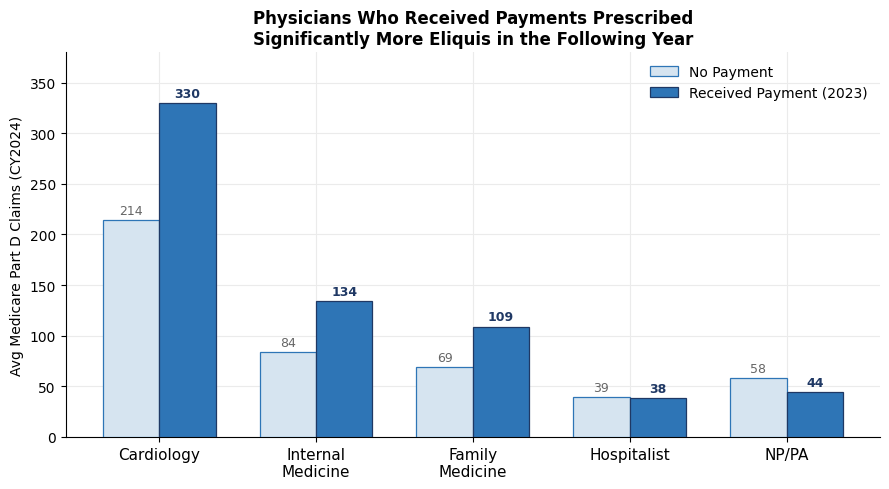

In [36]:
# Cell 30: Figure 1 — Paid vs. unpaid average claims by specialty (Eliquis)
# Headline bar chart showing the 50-60% claims premium for paid physicians.

DARK  = '#1F3864'; MID = '#2E75B6'; LIGHT = '#9DC3E6'; PALE = '#D6E4F0'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#EBEBEB', 'axes.axisbelow': True
})

specs   = ['Cardiology', 'Internal\nMedicine', 'Family\nMedicine', 'Hospitalist', 'NP/PA']
paid_v  = [330, 134, 109, 38, 44]
unpaid_v= [214,  84,  69, 39, 58]
x = np.arange(len(specs)); w = 0.36

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x-w/2, unpaid_v, w, label='No Payment', color=PALE, edgecolor=MID, linewidth=0.9, zorder=3)
b2 = ax.bar(x+w/2, paid_v,   w, label='Received Payment (2023)', color=MID, edgecolor=DARK, linewidth=0.9, zorder=3)
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, color='#666666')
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3, str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, color=DARK, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(specs, fontsize=11)
ax.set_ylabel('Avg Medicare Part D Claims (CY2024)'); ax.set_ylim(0, 380)
ax.set_title('Physicians Who Received Payments Prescribed\nSignificantly More Eliquis in the Following Year', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig('fig1_paid_vs_unpaid.png', dpi=150, bbox_inches='tight')
plt.show()

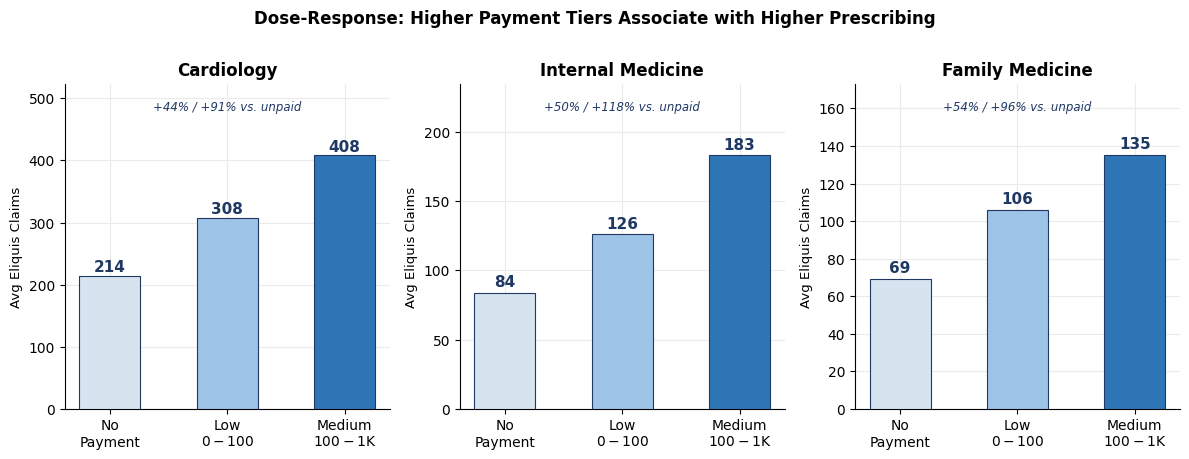

In [37]:
# Cell 31: Figure 2 — Dose-response across payment tiers (Eliquis, 3 specialties)
# Shows the monotonic increase in avg claims from No Payment → Low → Medium.

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
tiers  = ['No\nPayment', 'Low\n$0-$100', 'Medium\n$100-$1K']
colors = [PALE, LIGHT, MID]
data   = {'Cardiology':[214,308,408], 'Internal Medicine':[84,126,183], 'Family Medicine':[69,106,135]}

for ax, (spec, vals) in zip(axes, data.items()):
    bars = ax.bar(tiers, vals, color=colors, edgecolor=DARK, linewidth=0.8, width=0.52, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, str(val), ha='center', va='bottom', fontsize=11, fontweight='bold', color=DARK)
    pct_low = round((vals[1]-vals[0])/vals[0]*100)
    pct_med = round((vals[2]-vals[0])/vals[0]*100)
    ax.set_title(spec, fontsize=12, fontweight='bold')
    ax.set_ylabel('Avg Eliquis Claims', fontsize=9.5)
    ax.set_ylim(0, max(vals)*1.28)
    ax.text(0.5, 0.95, f'+{pct_low}% / +{pct_med}% vs. unpaid', transform=ax.transAxes, ha='center', va='top', fontsize=8.5, color=DARK, style='italic')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Dose-Response: Higher Payment Tiers Associate with Higher Prescribing', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_dose_response.png', dpi=150, bbox_inches='tight')
plt.show()

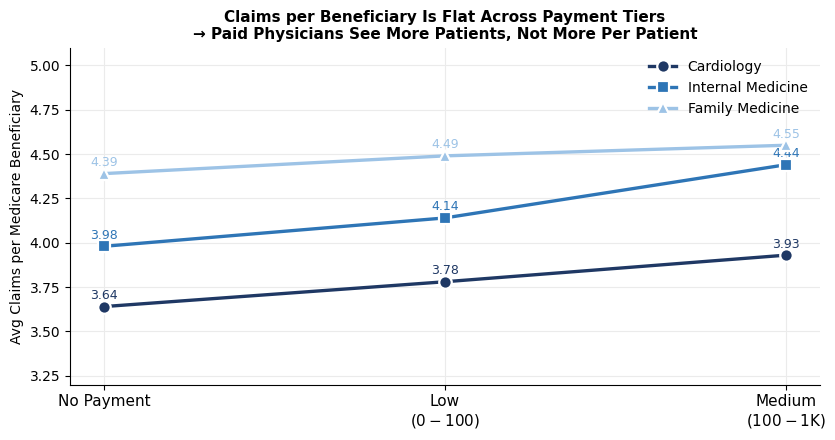

In [38]:
# Cell 32: Figure 3 — Claims per beneficiary (flat) — the mechanistic finding
# If payments changed per-patient prescribing, this line would rise with payment tier.
# The near-flat trajectories indicate paid physicians see more patients, not prescribe more per patient.

fig, ax = plt.subplots(figsize=(8.5, 4.5))
t3 = ['No Payment', 'Low\n($0-$100)', 'Medium\n($100-$1K)']
cpb = {'Cardiology':[3.64,3.78,3.93], 'Internal Medicine':[3.98,4.14,4.44], 'Family Medicine':[4.39,4.49,4.55]}
mks = ['o','s','^']; lcs = [DARK, MID, LIGHT]
x   = np.arange(3)

for (spec, vals), mk, lc in zip(cpb.items(), mks, lcs):
    ax.plot(x, vals, marker=mk, color=lc, linewidth=2.4, markersize=9, markeredgecolor='white', markeredgewidth=1.6, label=spec, zorder=4)
    for xi, v in zip(x, vals): ax.text(xi, v+0.025, f'{v:.2f}', ha='center', va='bottom', fontsize=9, color=lc)

ax.set_xticks(x); ax.set_xticklabels(t3, fontsize=11)
ax.set_ylabel('Avg Claims per Medicare Beneficiary'); ax.set_ylim(3.2, 5.1)
ax.set_title('Claims per Beneficiary Is Flat Across Payment Tiers\n→ Paid Physicians See More Patients, Not More Per Patient', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_claims_per_bene.png', dpi=150, bbox_inches='tight')
plt.show()

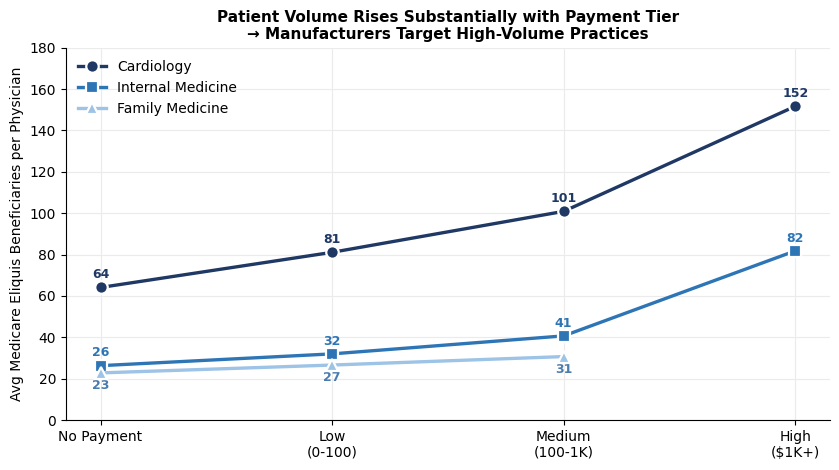

In [39]:
# Cell 33: Figure 4 — Beneficiaries by payment tier (rising)
# Counterpart to Figure 3: while claims/bene is flat, total beneficiaries rise.
# This confirms the mechanism is manufacturer targeting of high-volume practices.

fig, ax = plt.subplots(figsize=(8.5, 4.8))
t4 = ['No Payment', 'Low\n(0-100)', 'Medium\n(100-1K)', 'High\n($1K+)']
benes = {'Cardiology':[64.1,81.1,100.9,151.7], 'Internal Medicine':[26.3,32.0,40.7,81.8], 'Family Medicine':[22.8,26.6,30.7,None]}
x = np.arange(4)

for (spec, vals), mk, lc in zip(benes.items(), mks, lcs):
    yv = [v if v is not None else np.nan for v in vals]
    ax.plot(x, yv, marker=mk, color=lc, linewidth=2.4, markersize=9, markeredgecolor='white', markeredgewidth=1.6, label=spec, zorder=4)

card_pts = [(0,64.1,'64'),(1,81.1,'81'),(2,100.9,'101'),(3,151.7,'152')]
im_pts   = [(0,26.3,'26'),(1,32.0,'32'),(2,40.7,'41'),(3,81.8,'82')]
fm_pts   = [(0,22.8,'23'),(1,26.6,'27'),(2,30.7,'31')]

for xi,yv,lbl in card_pts: ax.text(xi, yv+3, lbl, ha='center', va='bottom', fontsize=9, color=DARK, fontweight='bold')
for xi,yv,lbl in im_pts:   ax.text(xi, yv+3, lbl, ha='center', va='bottom', fontsize=9, color=MID,  fontweight='bold')
for xi,yv,lbl in fm_pts:   ax.text(xi, yv-3, lbl, ha='center', va='top',    fontsize=9, color='#4A7BAF', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(t4, fontsize=10)
ax.set_ylabel('Avg Medicare Eliquis Beneficiaries per Physician')
ax.set_title('Patient Volume Rises Substantially with Payment Tier\n→ Manufacturers Target High-Volume Practices', fontsize=11, fontweight='bold')
ax.legend(fontsize=10, frameon=False, loc='upper left'); ax.set_ylim(0, 180)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_beneficiaries.png', dpi=150, bbox_inches='tight')
plt.show()

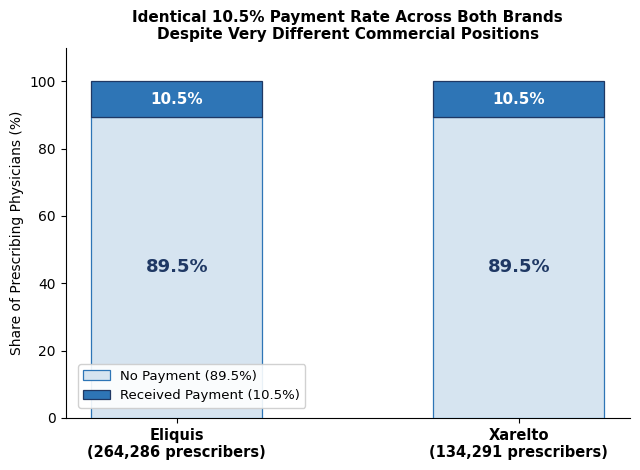

In [40]:
# Cell 34: Figure 5 — Identical 10.5% payment rate across both brands
# The 10.5% labels sit inside the dark blue segment in white text.
# Legend placed lower-left to avoid overlap.

fig, ax = plt.subplots(figsize=(6.5, 4.8))
brands = ['Eliquis\n(264,286 prescribers)', 'Xarelto\n(134,291 prescribers)']
x = np.arange(2); w = 0.50

ax.bar(x, [89.5,89.5], w, color=PALE, edgecolor=MID, linewidth=0.9, label='No Payment (89.5%)', zorder=3)
ax.bar(x, [10.5,10.5], w, bottom=[89.5,89.5], color=MID, edgecolor=DARK, linewidth=0.9, label='Received Payment (10.5%)', zorder=3)
for xi in x:
    ax.text(xi, 44.75, '89.5%', ha='center', va='center', fontsize=13, color=DARK, fontweight='bold')
    ax.text(xi, 94.75, '10.5%', ha='center', va='center', fontsize=11, color='white', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(brands, fontsize=10.5, fontweight='bold')
ax.set_ylabel('Share of Prescribing Physicians (%)'); ax.set_ylim(0, 110); ax.grid(False)
ax.set_title('Identical 10.5% Payment Rate Across Both Brands\nDespite Very Different Commercial Positions', fontsize=11, fontweight='bold')
ax.legend(fontsize=9.5, frameon=True, framealpha=0.9, loc='lower left', bbox_to_anchor=(0.01, 0.01))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_payment_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Cell 35: Export all key summary tables to CSV for use in the report

# Master summary by specialty and payment tier
summary = con.sql("""
    SELECT brand, specialty_bucket, payment_tier,
        COUNT(*) AS num_prescribers,
        ROUND(AVG(total_claims), 1) AS avg_claims,
        ROUND(AVG(total_drug_cost), 0) AS avg_drug_cost
    FROM doac_master_analysis
    GROUP BY brand, specialty_bucket, payment_tier
    ORDER BY brand, specialty_bucket,
        CASE payment_tier
            WHEN 'No Payment' THEN 0 WHEN 'Low ($0-$100)' THEN 1
            WHEN 'Medium ($100-$1000)' THEN 2 WHEN 'High ($1000+)' THEN 3
        END
""").df()
summary.to_csv('doac_summary_by_specialty_tier.csv', index=False)

# State summary
state_summary.to_csv('doac_summary_by_state.csv', index=False)

print('All CSV exports complete.')
print(f'Summary table rows: {len(summary)}')

All CSV exports complete.
Summary table rows: 42
